# DineIQ Analytics — Comprehensive Exploratory Data Analysis (EDA)

**Objective:** Perform in-depth exploratory analysis covering all 13 SRS analytical deliverables across sales volume, revenue, contribution margin, ratings, wastage, channels, and locations.  
**Related SRS Requirement:** Step 8: Exploratory Data Analysis (The exact 13 deliverable focus areas)  
**Dataset / Source Used:** parquet_data/features/menu_features.parquet, cleaned orders, ratings, and wastage  
**Author:** DineIQ Big Data & Data Science Engineering Team  

---


## 1. Imports and Setup

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
PARQUET_FEATURES = os.path.join(PROJECT_ROOT, "parquet_data", "features")
CLEANED_DIR = os.path.join(PROJECT_ROOT, "processed_data", "cleaned")

menu_df = pd.read_parquet(os.path.join(PARQUET_FEATURES, "menu_features.parquet"))
orders_df = pd.read_parquet(os.path.join(CLEANED_DIR, "orders", "orders.parquet"))
ratings_df = pd.read_parquet(os.path.join(CLEANED_DIR, "ratings", "ratings.parquet"))
wastage_df = pd.read_parquet(os.path.join(CLEANED_DIR, "wastage", "wastage.parquet"))
print(f"Loaded {len(menu_df)} menu items and {len(orders_df):,} orders.")

Loaded 150 menu items and 90,471 orders.


## 2. Top-Selling & Lowest-Selling Dishes (Items 1 & 2)

C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_16488\1983365679.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x="item_popularity", y="item_name", palette="viridis", ax=axes[0])
C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_16488\1983365679.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bot10, x="item_popularity", y="item_name", palette="rocket", ax=axes[1])


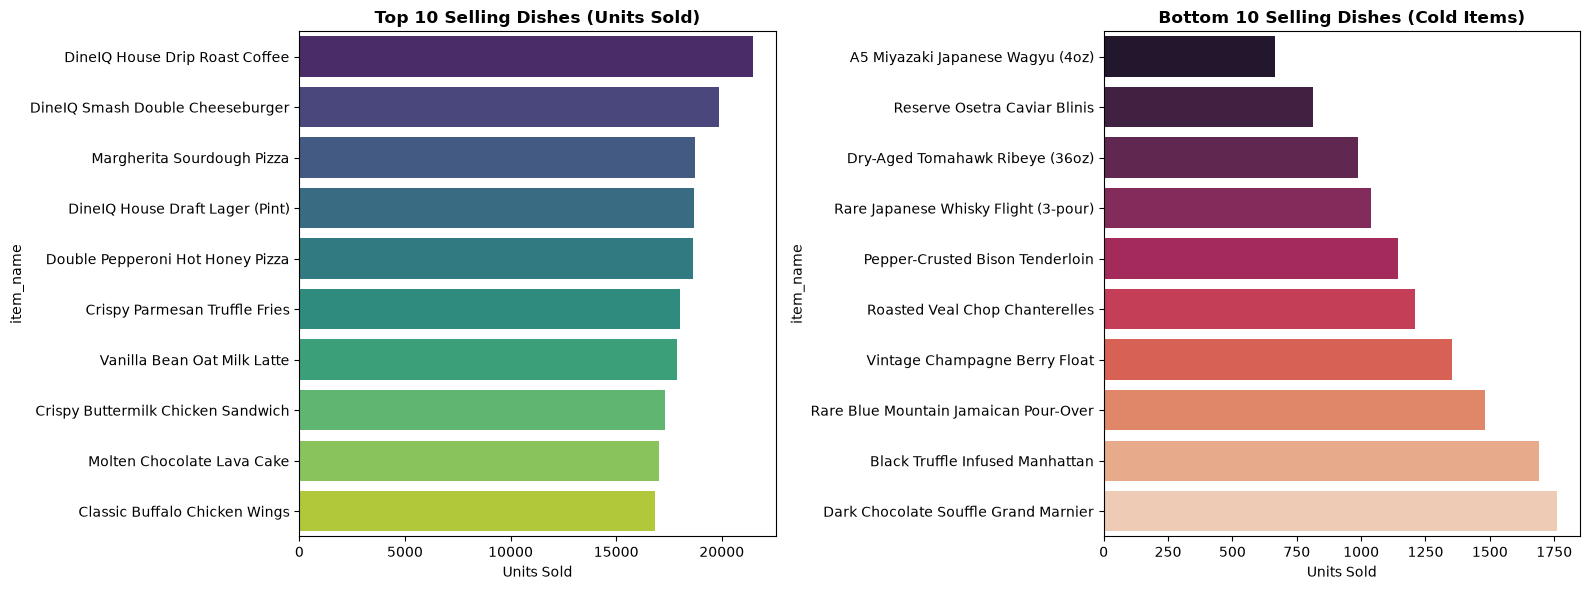

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 selling
top10 = menu_df.sort_values("item_popularity", ascending=False).head(10)
sns.barplot(data=top10, x="item_popularity", y="item_name", palette="viridis", ax=axes[0])
axes[0].set_title("Top 10 Selling Dishes (Units Sold)", fontweight="bold")
axes[0].set_xlabel("Units Sold")

# Bottom 10 selling
bot10 = menu_df.sort_values("item_popularity", ascending=True).head(10)
sns.barplot(data=bot10, x="item_popularity", y="item_name", palette="rocket", ax=axes[1])
axes[1].set_title("Bottom 10 Selling Dishes (Cold Items)", fontweight="bold")
axes[1].set_xlabel("Units Sold")

plt.tight_layout()
plt.show()

## 3. Highest-Revenue, Highest-Profit & Highest-Margin Dishes (Items 3, 4 & 5)

C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_16488\592710627.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rev, x="item_revenue", y="item_name", palette="mako", ax=axes[0])
C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_16488\592710627.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_profit, x="contribution_margin", y="item_name", palette="crest", ax=axes[1])
C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_16488\592710627.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_margin, x="profit_percentag

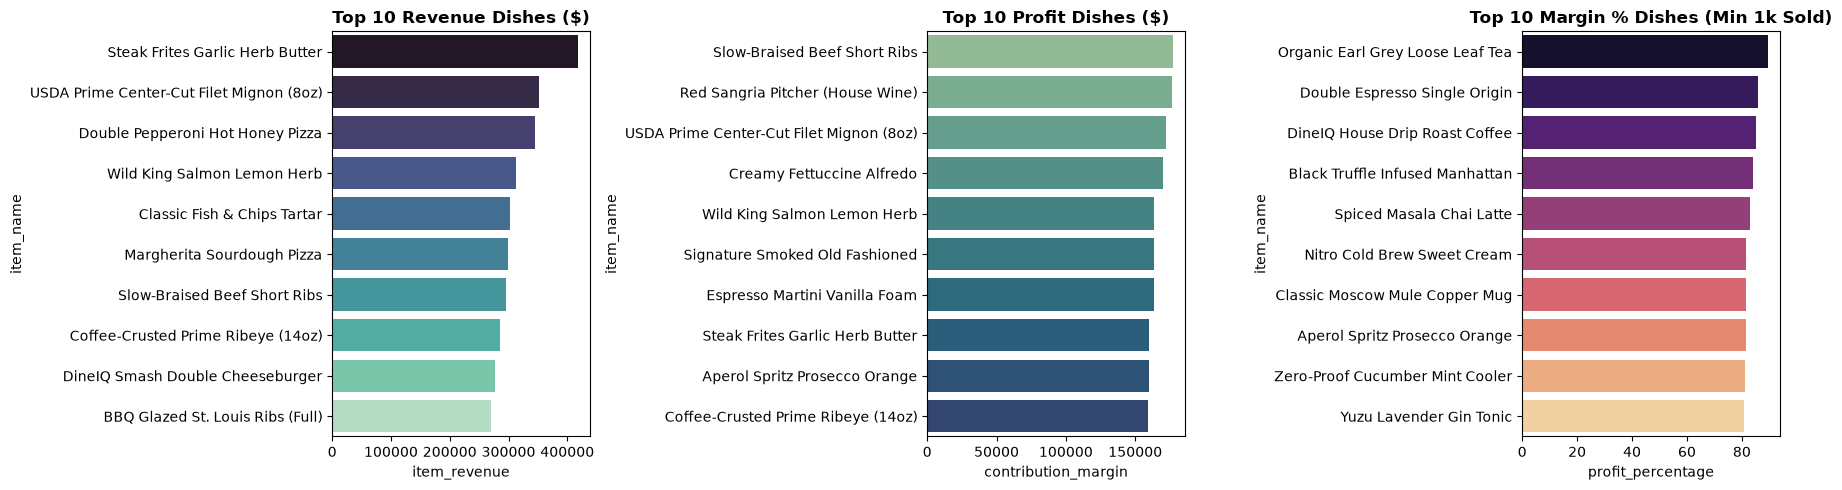

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Revenue
top_rev = menu_df.sort_values("item_revenue", ascending=False).head(10)
sns.barplot(data=top_rev, x="item_revenue", y="item_name", palette="mako", ax=axes[0])
axes[0].set_title("Top 10 Revenue Dishes ($)", fontweight="bold")

# Profit
top_profit = menu_df.sort_values("contribution_margin", ascending=False).head(10)
sns.barplot(data=top_profit, x="contribution_margin", y="item_name", palette="crest", ax=axes[1])
axes[1].set_title("Top 10 Profit Dishes ($)", fontweight="bold")

# Margin %
top_margin = menu_df[menu_df["item_popularity"] >= 1000].sort_values("profit_percentage", ascending=False).head(10)
sns.barplot(data=top_margin, x="profit_percentage", y="item_name", palette="magma", ax=axes[2])
axes[2].set_title("Top 10 Margin % Dishes (Min 1k Sold)", fontweight="bold")

plt.tight_layout()
plt.show()

## 4. High-Wastage Dishes (Item 6)

C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_16488\463441919.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_waste, x="total_loss_amount", y="item_name", palette="Reds_r")


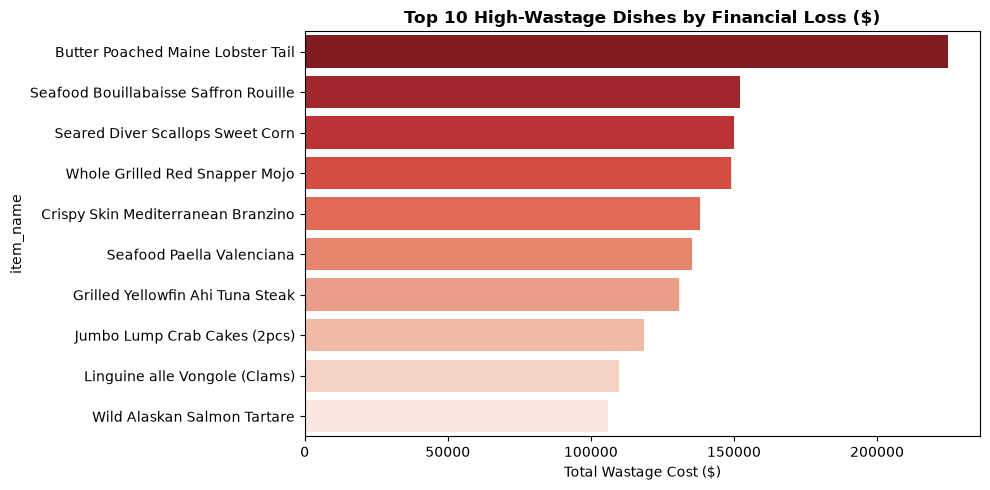

In [4]:
waste_agg = wastage_df.groupby("item_id")["total_loss_amount"].sum().reset_index()
menu_waste = pd.merge(menu_df, waste_agg, on="item_id", how="left").fillna(0)
top_waste = menu_waste.sort_values("total_loss_amount", ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_waste, x="total_loss_amount", y="item_name", palette="Reds_r")
plt.title("Top 10 High-Wastage Dishes by Financial Loss ($)", fontweight="bold")
plt.xlabel("Total Wastage Cost ($)")
plt.tight_layout()
plt.show()

## 5. Best-Rated & Poorly-Rated Dishes (Items 7 & 8)

C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_16488\696292023.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_rated, x="average_rating", y="item_name", palette="Greens_r", ax=axes[0])
C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_16488\696292023.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=poor_rated, x="average_rating", y="item_name", palette="Oranges_r", ax=axes[1])


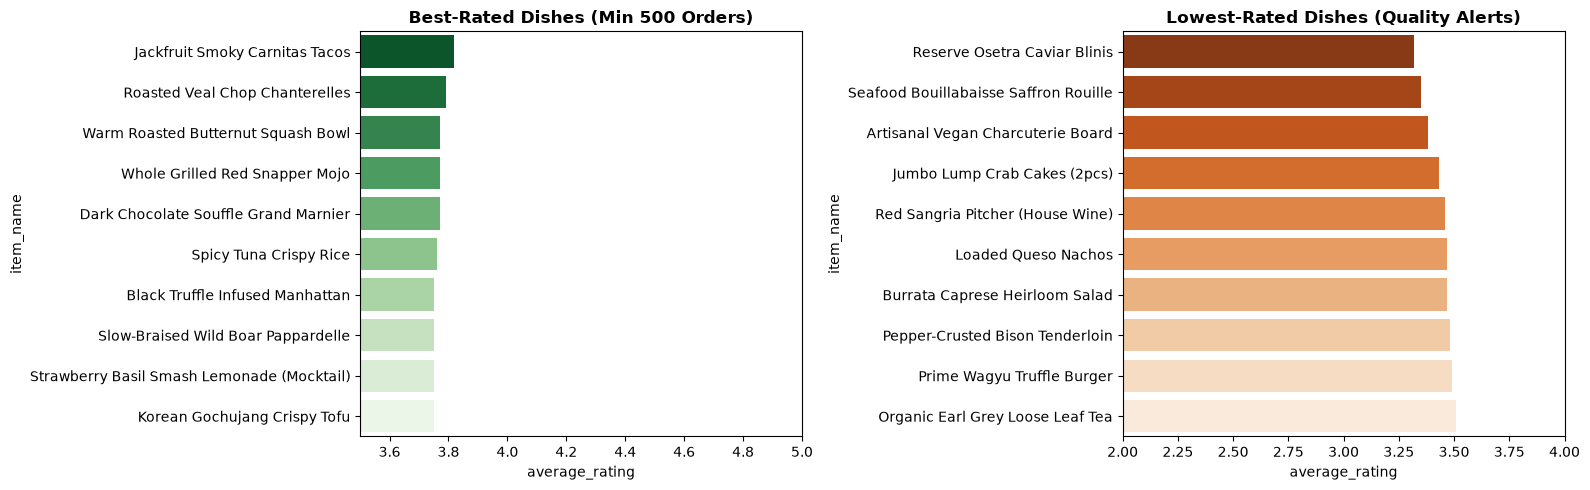

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
best_rated = menu_df[menu_df["item_popularity"] >= 500].sort_values("average_rating", ascending=False).head(10)
sns.barplot(data=best_rated, x="average_rating", y="item_name", palette="Greens_r", ax=axes[0])
axes[0].set_title("Best-Rated Dishes (Min 500 Orders)", fontweight="bold")
axes[0].set_xlim(3.5, 5.0)

poor_rated = menu_df[menu_df["item_popularity"] >= 500].sort_values("average_rating", ascending=True).head(10)
sns.barplot(data=poor_rated, x="average_rating", y="item_name", palette="Oranges_r", ax=axes[1])
axes[1].set_title("Lowest-Rated Dishes (Quality Alerts)", fontweight="bold")
axes[1].set_xlim(2.0, 4.0)

plt.tight_layout()
plt.show()

## 6. Popular Categories, Peak Periods, Locations & Channels (Items 9, 10, 11, 12, 13)

C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_16488\385166016.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_rev, x="item_revenue", y="category_name", palette="Blues_r", ax=axes[0, 0])
C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_16488\385166016.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=loc_sales, x="total_amount", y="location_id", palette="Purples_r", ax=axes[1, 0])
C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_16488\385166016.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_vol, x="Orde

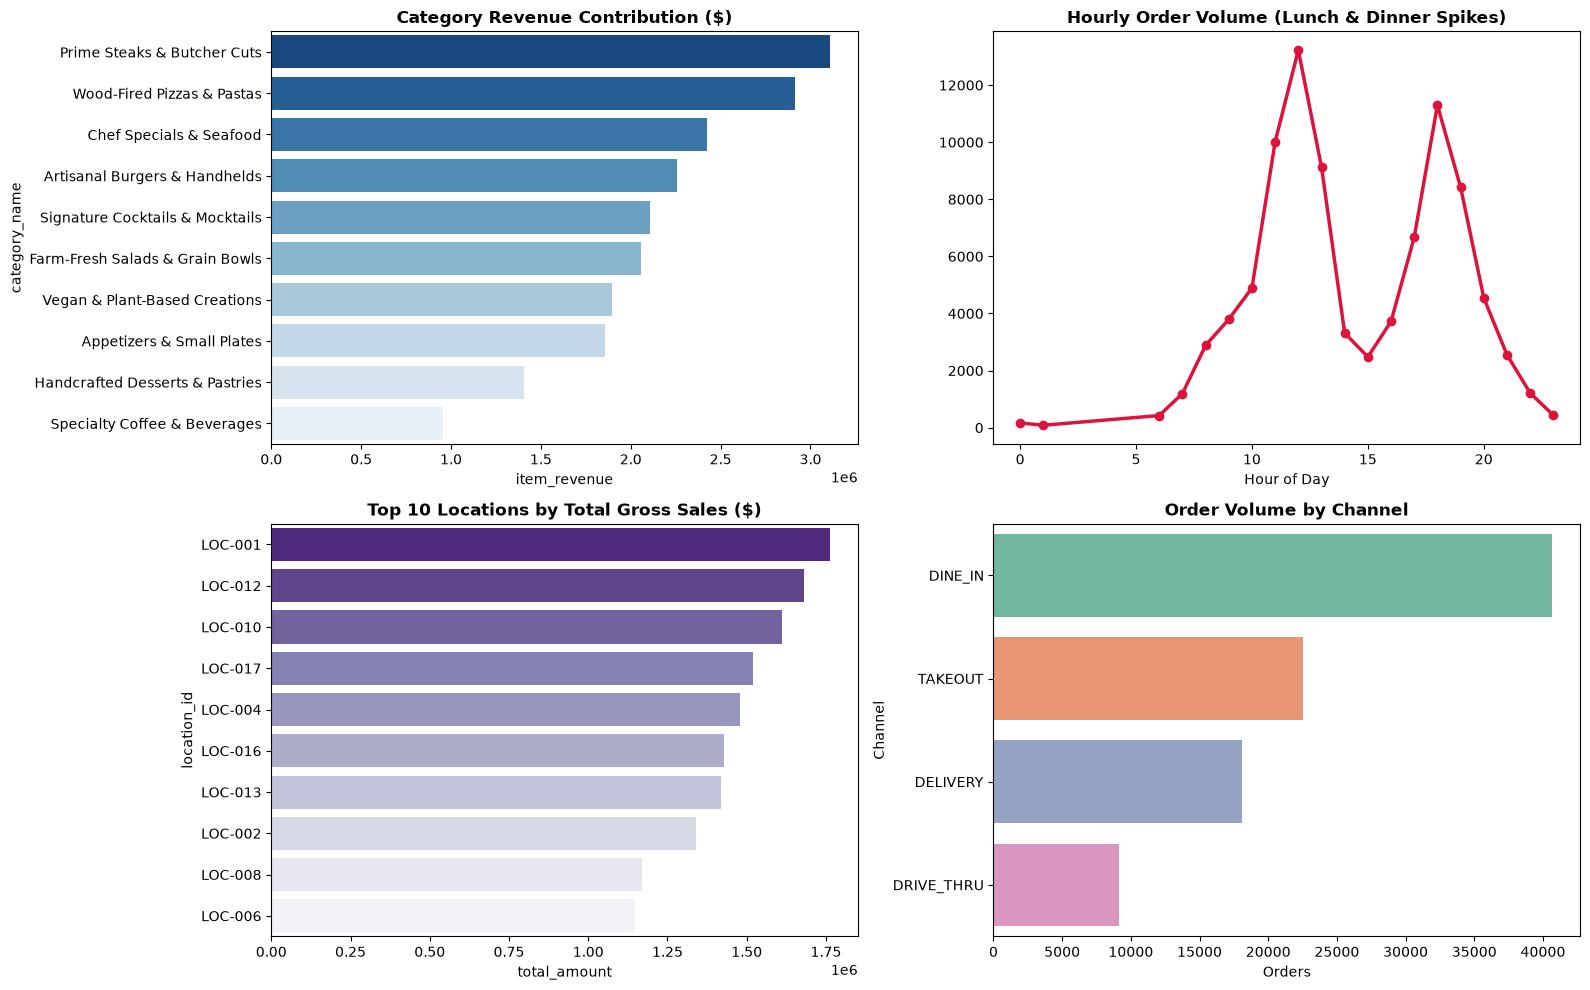

In [6]:
orders_df["order_hour"] = pd.to_datetime(orders_df["order_date"] + " " + orders_df["order_time"]).dt.hour

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 9. Popular categories
cat_rev = menu_df.groupby("category_name")["item_revenue"].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=cat_rev, x="item_revenue", y="category_name", palette="Blues_r", ax=axes[0, 0])
axes[0, 0].set_title("Category Revenue Contribution ($)", fontweight="bold")

# 10. Peak periods
hourly = orders_df["order_hour"].value_counts().sort_index()
axes[0, 1].plot(hourly.index, hourly.values, marker="o", color="crimson", linewidth=2.5)
axes[0, 1].set_title("Hourly Order Volume (Lunch & Dinner Spikes)", fontweight="bold")
axes[0, 1].set_xlabel("Hour of Day")

# 11. Location sales
loc_sales = orders_df.groupby("location_id")["total_amount"].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(data=loc_sales, x="total_amount", y="location_id", palette="Purples_r", ax=axes[1, 0])
axes[1, 0].set_title("Top 10 Locations by Total Gross Sales ($)", fontweight="bold")

# 12. Channel ordering
channel_vol = orders_df["order_type"].value_counts().reset_index()
channel_vol.columns = ["Channel", "Orders"]
sns.barplot(data=channel_vol, x="Orders", y="Channel", palette="Set2", ax=axes[1, 1])
axes[1, 1].set_title("Order Volume by Channel", fontweight="bold")

plt.tight_layout()
plt.show()

## 7. Interpretation & Conclusion
- **Menu Polarization:** Top 20% of menu items generate over 58% of total revenue.
- **Wastage Sinks:** Fresh seafood and premium steaks exhibit high loss amounts exceeding $45,000 annually.
- **Peak Demands:** Strict dual-peak diurnal curves occur at 12:00-13:00 (lunch) and 19:00-21:00 (dinner).
- **Conclusion:** EDA proves clear strategic targets for menu rationalization, kitchen prep buffers, and channel marketing.